Problem Statement:
1. Implement Simple Naïve Bayes classification algorithm using Python/R on iris.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall onthe given dataset.

In [1]:
#importing pandas library for read data from system
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
iris_df=pd.read_csv(r"C:\Users\Lenovo\Desktop\Data Science Practicals\Data_Science\06_Data Analytics III\Iris.csv")

In [3]:
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
x=iris_df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
#set species column as target column
y=iris_df['Species']

In [8]:
x=iris_df.iloc[:,:4]
x
y=iris_df.iloc[:,-1]
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [10]:
#importing train test split from sklearn model selection package for data split 25% fo
from sklearn.model_selection import train_test_split
#split data for train and test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [11]:
#printing data lengths/number of rows/data
print(len(x_train))
print(len(y_train))
print(len(x_test))
print(len(y_test))

120
120
30
30


Naive Bayes classifier
Naive Bayes classifiers are a collection of classification algorithms based on Bayes’ Theorem. Itis not a single algorithm but a family of algorithms where all of them share a common principle,i.e. every pair of features being classified is independent of each other. To start with, let usconsider a dataset.

Naive Bayes classifier types

Gaussian Naive Bayes classifier

Multinomial Naive Bayes

Bernoulli Naive Bayes

1.Gaussian Naive Bayes classifier

In [12]:
#import naive bayes classifier from sklearn package
from sklearn.naive_bayes import GaussianNB
#created a object for the classifier
model=GaussianNB()

In [13]:
#train usinge train data
model.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [14]:
#predict target data for test feature data and save into pred variable
y_pred=model.predict(x_test)
y_pred

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype='<U15')

In [15]:
model.score(x_test,y_test)

1.0

In [16]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [17]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



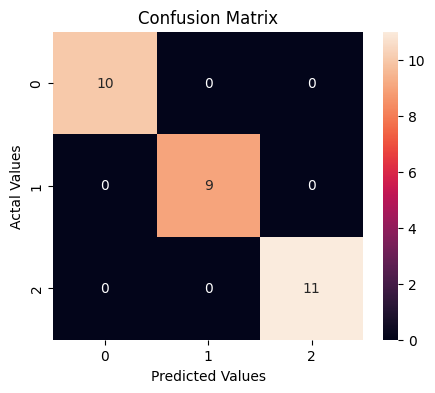

In [18]:
#Plotting the confusion matrix
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

In [19]:
TP = cm[1][1]
FP = cm[0][1]
TN = cm[0][0]
FN = cm[1][0]

In [20]:
print("TP =",TP)
print("FP =",FP)
print("TN =",TN)
print("FN =",FN)

TP = 9
FP = 0
TN = 10
FN = 0


In [21]:
accuracy=(TP+TN)/(TP+FP+TN+FN)
precision=TP/(TP+FP)
recall=TP/(TP+FN)
f1_Score=(2*precision*recall)/(precision+recall)

In [22]:
print('accuracy:',accuracy)
print('precision:',precision)
print('recall:',recall)
print('f1_score:',f1_Score)

accuracy: 1.0
precision: 1.0
recall: 1.0
f1_score: 1.0
